# HW 3: STFT, Features, and Regression (15 points)

For each markdown cell, add a cell (or cells) of code below. 
Reminders:
* This is an individual assignment. 
* If you use GenAI tools to assist you with your homework, remember to fill out the GenAI Usage Statement at the bottom of the notebook. Even if you use GenAI, you should not be directly copying the code.
* You may only use functions/packages we have discussed in class

Read in the following files from your "audio" folder.
- /audio/country.00000.wav
- /audio/hiphop.00000.wav
    
Ensure that amplitudes are normalized to between -1 and 1. 

## Part 1: STFT parameters and visualization (6 points)

#### Write your own STFT (3 points)

Write your own STFT function that will output a 2D matrix with shape (num_frames, num_bins), where each row contains the DFT of a single frame.

* Use a hop size equal to half the frame size (i.e., hop_size = frame_size // 2) so that frames overlap by 50%, and you should apply a hanning window to each frame (you may use `np.hanning()` for this.)

* The user should be able to vary the size of the frame (leave hop_size fixed at 50%).

*Note: You should use the built in numpy FFT function (instead of your DFT). This means you will have to work in powers of 2!*

In [66]:
import math
from scipy.io.wavfile import read
from scipy import signal
import scipy
import numpy as np
import matplotlib.pyplot as plt
import librosa
from IPython.display import Math, Image, Audio

In [ ]:
# your code here
def my_stft(audio_input, frame_size, sampling_rate = 44100):
    
    # Define frame_length (should be power of two based on input frame_size)
    frame_length = 2**(int(math.log(frame_size, 2)))
    # Define hop size is half the frame size
    hop_length = int(frame_length/2)

    # Define number of frames (m) we can extract with 50% overlap based on the total length of our signal
    # If the signal does not fit an integer number of frames, truncate
    n_mbins = int((len(audio_input) - frame_length)/hop_length) + 1
    audio_input = audio_input[0:hop_length*(n_mbins-1) + frame_length] # Ensure we don't get weird behvaiors at the end of our truncated thing

    # Define total number of frequency bins
    n_kbins = int(frame_length / 2 + 1)

    # Pre-allocate matrix for STFT. Remember it should be structured as [time_frames, frequency_bins]
    stft_matrix = np.zeros((n_mbins, n_kbins), dtype=complex)

    # Define window
    window = np.hamming(frame_length) 

    # Iterate through signal by frame
    for m in range(n_mbins):
        # index into the frame, apply window, apply fft over the frame, store in matrix
        frame = audio_input[m*hop_length:m*hop_length + frame_length]
        windowed = frame * window
        spectrum = np.fft.rfft(windowed)
        stft_matrix[m, :] = spectrum

    return stft_matrix

array([[-3.57924961e+04+0.00000000e+00j,  8.06875178e+04+4.60049763e+04j,
        -1.63979418e+05-8.99685776e+04j, ...,
        -9.31844516e+02+1.43914668e+03j,  2.23554339e+03+1.09327151e+03j,
         4.05908890e+03+0.00000000e+00j],
       [-3.38550212e+04+0.00000000e+00j,  8.80071637e+04+2.76265604e+04j,
        -4.75034179e+04-1.05042082e+05j, ...,
         3.68661624e+03+1.01164434e+02j, -4.42793422e+03+3.49624703e+03j,
         2.26978616e+03+0.00000000e+00j],
       [-4.26145430e+04+0.00000000e+00j,  6.25780913e+04+5.03679093e+04j,
        -2.76639777e+05-5.06831550e+03j, ...,
        -3.15637094e+03+2.97973725e+03j,  5.43597406e+03-3.36859110e+03j,
        -1.01474617e+04+0.00000000e+00j],
       ...,
       [-7.39946744e+03+0.00000000e+00j,  3.85491097e+05+1.81690445e+05j,
        -1.44063552e+06-1.25628186e+06j, ...,
         8.13448944e+03-6.72624244e+03j, -1.55257676e+04+1.22540312e+04j,
         2.63262177e+04+0.00000000e+00j],
       [ 1.45156921e+04+0.00000000e+00j,  1.

#### Apply your STFT function

Apply your STFT function to the audio files listed above (country and hiphop)

In [118]:
(fs1, data1) = read('../audio/hiphop.00000.wav')
data1 = data1 / np.max(abs(data1))
stft1 = my_stft(data1, 1024)
(fs2, data2) = read('../audio/country.00000.wav')
data2 = data2 / np.max(abs(data2))
stft2 = my_stft(data2, 1024)

#### Write your own spectrogram function (3 points)

Write your own spectrogram function (using `plt.pcolormesh()`) called `plot_spectrogram()` that takes the complex-valued STFT output from your above function, and the sampling rate, and plots a magnitude spectrogram in decibels.

The axes should be properly labeled (time on x-axis, Frequency on y-axis).

*Note: audio processing workflows and dataframe logic in general in Python commonly use rows = time. However, several plotting functions like pcolormesh() annoyingly expect rows = frequency and columns = time. Therefore, we simply add a step to 'transpose' our 2d array or matrix in our code below.*


In [62]:
# your code here
def plot_spectrogram(stft_matrix, frame_size, sampling_rate):

    # Take magnitude and convert to decibels
    magnitude = np.abs(stft_matrix).T  # Transpose so rows = frequencies
    magnitude_db = 20 * np.log10(magnitude + 1e-6)  # avoid log(0)

    # Time and frequency axes
    num_frames = stft_matrix.shape[0] # total number of frames
    hop_size = frame_size / 2   # recall it was 50% of the frame size
    duration = (num_frames * hop_size) / sampling_rate   # find duration
    
    # Make a time axis by taking the total duration and dividing the timeline according to the number of frames:
    time_axis = np.linspace(0, duration, num_frames)
    # Ditto for frequency axis according to the number of bins
    freq_axis = np.linspace(0, sampling_rate/2, magnitude.shape[0])

    # Plot only up to Nyquist frequency by indexing your magnitude vector
    plt.pcolormesh(time_axis, freq_axis, magnitude_db)
    plt.ylabel("Frequency (Hz)")
    plt.xlabel("Time (s)")
    plt.title("Spectrogram")
    

Plot the spectrogram of the country and hiphop audio files

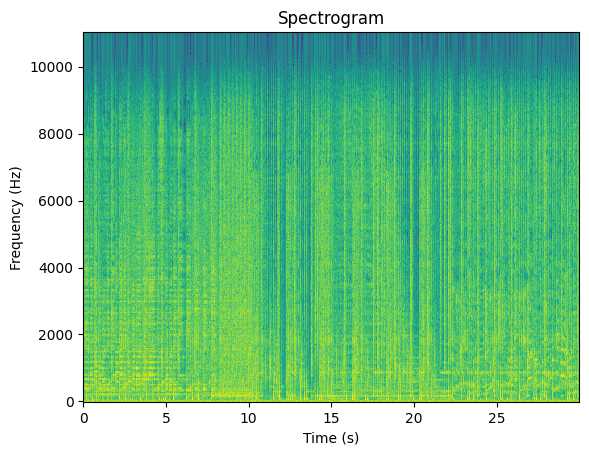

In [143]:
plot_spectrogram(stft1, 1024, fs1)

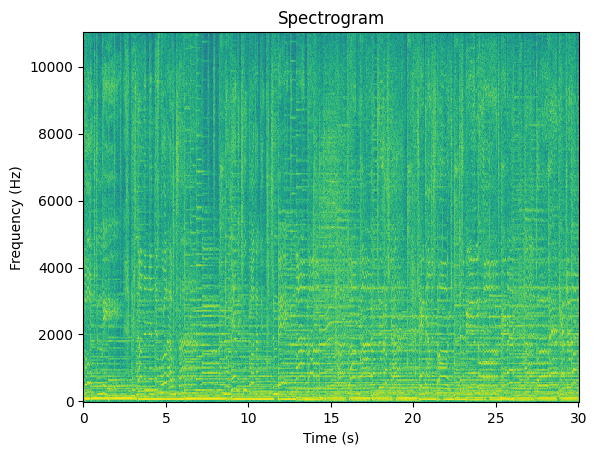

In [142]:
plot_spectrogram(stft2, 1024, fs2)

## Part 2: Feature Extraction (4 points)

We will perform feature extraction and compare the two audio files above.

Extract the following features for each file (you may use librosa functions):
- RMSE
- Spectral Centroid
- Spectral Flux
- ZCR

For each feature:
- graph the results of each feature
- briefly describe what the feature might tell us perceptually
- briefly describe whether or not this might be a useful feature for classification (based on the graphs)

1 point for each correct feature calculation and associated explanation/reasoning

C:\Users\Jennefer Bennett\AppData\Local\Temp\ipykernel_4672\311070831.py:4: FutureWarning: Pass y=[-0.17154617 -0.02200421  0.01983783 ...  0.07771107  0.03927333
 -0.0213543 ] as keyword args. From version 0.10 passing these as positional arguments will result in an error
  hiphopRMSE = librosa.feature.rms(data1)[0]
C:\Users\Jennefer Bennett\AppData\Local\Temp\ipykernel_4672\311070831.py:6: FutureWarning: Pass y=[-0.17343275 -0.25190358 -0.0550361  ...  0.29222393  0.19446088
  0.05479938] as keyword args. From version 0.10 passing these as positional arguments will result in an error
  countryRMSE = librosa.feature.rms(data2)[0]


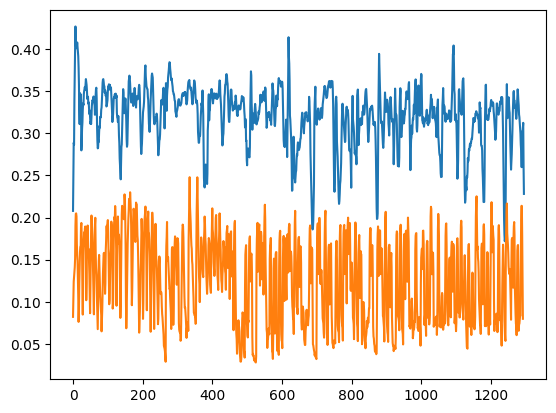

In [144]:
from librosa import frames_to_time, stft, amplitude_to_db, display

# RMSE for hiphop
hiphopRMSE = librosa.feature.rms(data1)[0]
# RMSE for country
countryRMSE = librosa.feature.rms(data2)[0]
# plotting
plt.plot(countryRMSE)
plt.plot(hiphopRMSE)

Your RMSE explantion here!

RMSE is a measurement of the intensity of a signal. We tend to here music with greater RMSE variability as being more percussive. In these two examples the country music tends to have a higher overall RMSE (volume) but a comparable distribution making it a poor candidate to choose from for diffrenating the two generes. 

C:\Users\Jennefer Bennett\AppData\Local\Temp\ipykernel_4672\120431765.py:2: FutureWarning: Pass y=[-0.17154617 -0.02200421  0.01983783 ...  0.07771107  0.03927333
 -0.0213543 ] as keyword args. From version 0.10 passing these as positional arguments will result in an error
  hiphopSC = librosa.feature.spectral_centroid(data1)[0]
C:\Users\Jennefer Bennett\AppData\Local\Temp\ipykernel_4672\120431765.py:4: FutureWarning: Pass y=[-0.17343275 -0.25190358 -0.0550361  ...  0.29222393  0.19446088
  0.05479938] as keyword args. From version 0.10 passing these as positional arguments will result in an error
  countrySC = librosa.feature.spectral_centroid(data2)[0]


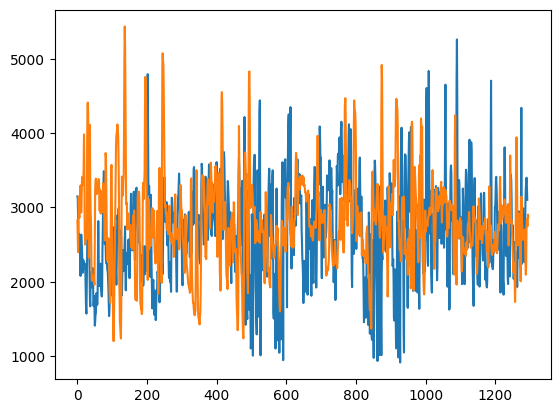

In [117]:
# Spectral Centroid for hiphop
hiphopSC = librosa.feature.spectral_centroid(data1)[0]
# Spectral Centroid for country
countrySC = librosa.feature.spectral_centroid(data2)[0]
# plotting
plt.plot(hiphopSC)
plt.plot(countrySC)

Your centroid explanation here!

Spectral centriod is a measurement of the center of spectral energy and is realted to the brightness of a tone. The limits and rate of change of spectral centriod seems to be fairly consitent between both generes making it a poor indicator.

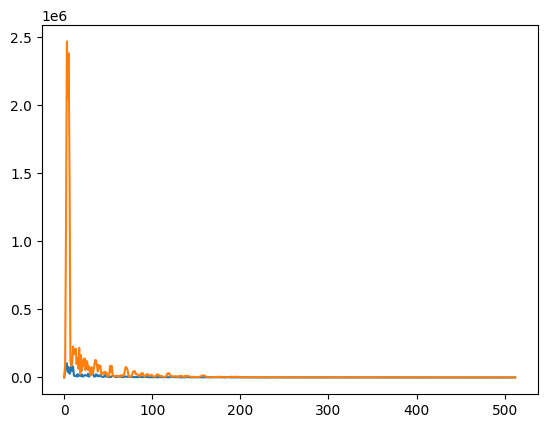

In [123]:
# spectral flux for hiphop
hiphopSF = np.sum(np.diff(np.abs(stft1), axis=1)**2, axis=0)
hiphopSF = np.concatenate(([0], hiphopSF))
# spectral flux for country
countrySF = np.sum(np.diff(np.abs(stft2), axis=1)**2, axis=0)
countrySF = np.concatenate(([0], countrySF))
# plotting
plt.plot(hiphopSF)
plt.plot(countrySF)

Your spectral flux explanation here!

Spectral flux is the measurment of how quickly the power spectrum of a signal is changing. In this case the spectral flux of the country music is significantly higher than the spectral flux of the hiphop music making it a good indicator.

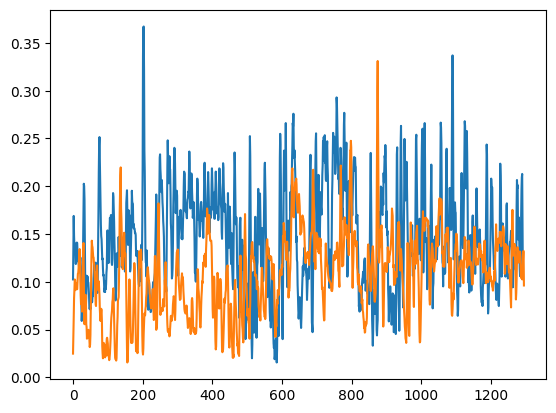

In [125]:
# ZCR for hiphop
hiphopZCR = librosa.feature.zero_crossing_rate(data1)[0]
# ZCR for country
countryZCR = librosa.feature.zero_crossing_rate(data2)[0]
# plotting
plt.plot(hiphopZCR)
plt.plot(countryZCR)

Your ZCR explanation here!

Zero crossing rate is the rate of sign changes of a signal during a peroid of time. Zero crossing rate correlates percepaully to the perodicity of the sound and its frequency. Here, the zcr of hiphop is overall higher and more varied making it a good indicator.

## Part 3: Binomial Logistic Regression (5 points)

Like in activity 7, you will build a binomial classifier with logistic regression. You will use the GTZAN genre dataset 'features_30_sec.csv' this time to classify hiphop vs country music.

### Explore the data and select your features (3 points)

Use graphing and correlation techniques to determine 5 features you will use for your classification.

You must at a minimum create 1 bar graph and 1 box plot in addition to computing the correlation between the features you select.

Construct your Pandas dataframe for your chosen features. Remember you may want to do some scaling and normalization.

Text(0.5, 1.0, 'Tempo')

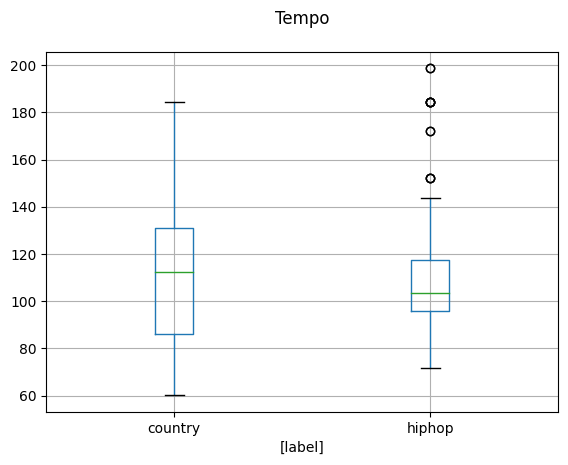

In [130]:
from sklearn import preprocessing
import pandas as pd

df = pd.read_csv('../Datasets/features_30_sec.csv')
columns_to_keep = ['filename', 'label', 'tempo']
df = df[columns_to_keep]
genres = ['hiphop', 'country']
df = df[df['label'].isin(genres)]

fig, ax = plt.subplots()
df.boxplot(by='label', ax=ax)
#get rid of default title
fig.suptitle("")
#set your own title
ax.set_title('Tempo', pad=20)

Text(0.5, 1.0, 'Rms_Mean')

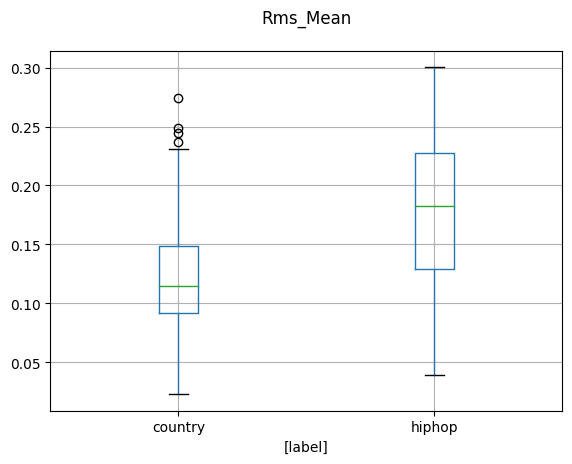

In [131]:
df = pd.read_csv('../Datasets/features_30_sec.csv')
columns_to_keep = ['filename', 'label', 'rms_mean']
df = df[columns_to_keep]
genres = ['hiphop', 'country']
df = df[df['label'].isin(genres)]

fig, ax = plt.subplots()
df.boxplot(by='label', ax=ax)
#get rid of default title
fig.suptitle("")
#set your own title
ax.set_title('Rms_Mean', pad=20)

Text(0.5, 1.0, 'Spectral_Centroid_mean')

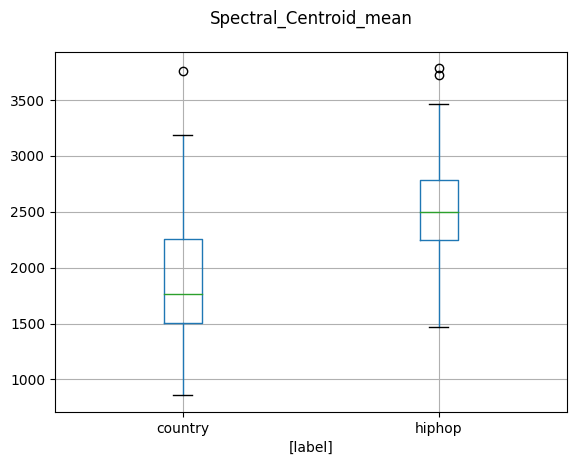

In [132]:
df = pd.read_csv('../Datasets/features_30_sec.csv')
columns_to_keep = ['filename', 'label', 'spectral_centroid_mean']
df = df[columns_to_keep]
genres = ['hiphop', 'country']
df = df[df['label'].isin(genres)]

fig, ax = plt.subplots()
df.boxplot(by='label', ax=ax)
#get rid of default title
fig.suptitle("")
#set your own title
ax.set_title('Spectral_Centroid_mean', pad=20)

Text(0.5, 1.0, 'Zero_Crossing_Rate_Mean')

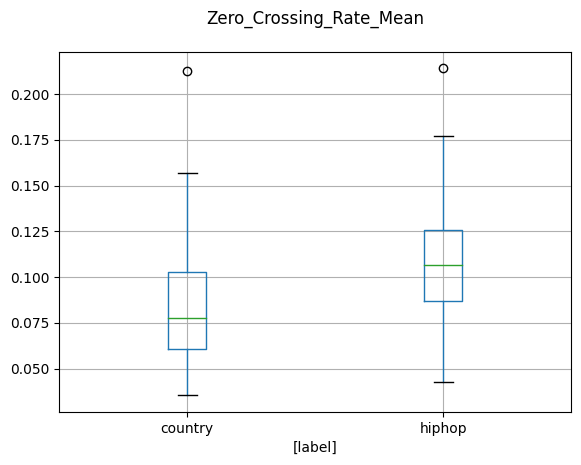

In [133]:
df = pd.read_csv('../Datasets/features_30_sec.csv')
columns_to_keep = ['filename', 'label', 'zero_crossing_rate_mean']
df = df[columns_to_keep]
genres = ['hiphop', 'country']
df = df[df['label'].isin(genres)]

fig, ax = plt.subplots()
df.boxplot(by='label', ax=ax)
#get rid of default title
fig.suptitle("")
#set your own title
ax.set_title('Zero_Crossing_Rate_Mean', pad=20)

Text(0.5, 1.0, 'Rms_Mean')

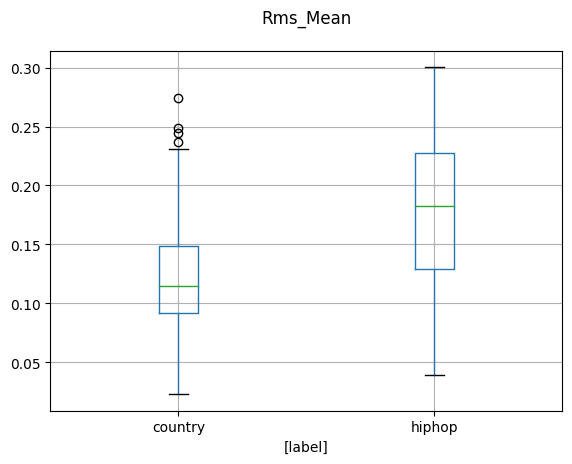

In [134]:
df = pd.read_csv('../Datasets/features_30_sec.csv')
columns_to_keep = ['filename', 'label', 'rms_mean']
df = df[columns_to_keep]
genres = ['hiphop', 'country']
df = df[df['label'].isin(genres)]

fig, ax = plt.subplots()
df.boxplot(by='label', ax=ax)
#get rid of default title
fig.suptitle("")
#set your own title
ax.set_title('Rms_Mean', pad=20)

### Train/Test Split

Use sklearn to split your data into testing and training sets. Remember you will need to define your categories, predictors, and test size. Use 30% test size.

In [138]:
df = pd.read_csv('../Datasets/features_30_sec.csv')
columns_to_keep = ['label', 'rms_mean', 'spectral_centroid_mean', 'rolloff_mean', 'zero_crossing_rate_mean', 'tempo']
df = df[columns_to_keep]
genres = ['hiphop', 'classical']
df = df[df['label'].isin(genres)]
label = pd.get_dummies(df["label"], drop_first=True)
df.drop(["label"], axis=1, inplace=True)
data_dmy = pd.concat([label, df], axis=1)
data_dmy.reset_index(drop=True, inplace=True)

scaler = preprocessing.StandardScaler()
scaled_data_dmy = scaler.fit_transform(data_dmy)
scaleddf = pd.DataFrame(scaled_data_dmy, columns=['label', 'rms_mean', 'spectral_centroid_mean', 'rolloff_mean', 'zero_crossing_rate_mean', 'tempo'])

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

categories = scaleddf.iloc[:,1:]
predictors = scaleddf.iloc[:,0]
pred_train, pred_test, cat_train, cat_test = train_test_split(categories, predictors, test_size = .3, random_state=25)

### Train the Model and Evaluate (2 points)

Train the model using logistic regression.

Calculate the confusion matrix (and view as a data frame). Calculate the accuracy, precision, recall, and F1 scores.

Explain what the confusion matrix and accuracy tell us about your model.

In [140]:
model = LogisticRegression(solver='lbfgs') #for simple binary logistic regression we can use all default parameters
model.fit(pred_train, cat_train)
predictions = model.predict(pred_test)

coeffs = pd.Series(model.coef_[0])
coeffs = dict(zip(data_dmy.columns[1:], model.coef_[0]))
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(cat_test, predictions)#parameters are y_truth (i.e.,Ground truth (correct) target values), y_pred (i.e., predicted values from model).
pd.DataFrame(cm, columns=['Hiphop','Country'], index=['Predicts_Hiphop','Predicts_Country'])

,Hiphop,Country
Predicts_Hiphop,28,1
Predicts_Country,1,30


In [141]:
from sklearn.metrics import classification_report, precision_recall_fscore_support
print(classification_report(cat_test, predictions))

              precision    recall  f1-score   support

        -1.0       0.97      0.97      0.97        29
         1.0       0.97      0.97      0.97        31

    accuracy                           0.97        60
   macro avg       0.97      0.97      0.97        60
weighted avg       0.97      0.97      0.97        60



Your model interpretation here!

My model was accurate only misidentifying 2 songs. (Of the 60 entries 58 were correct with making of accuracy of 58/60 which aprox. equals 97%)

print(classification_report(cat_test, predictions))